# 📊 Data Visualization — Practice Worksheet
### Tasks covering Matplotlib, Seaborn, Bokeh & Plotly

---

> 📌 **Instructions**
> - Complete **all 9 tasks** in order.
> - Each task builds on concepts covered in the lecture.
> - Fill in the `# YOUR CODE HERE` sections only — do not change the task descriptions.
> - Run each cell after completing it to verify your output.

**Libraries you will need:** `matplotlib`, `seaborn`, `bokeh`, `plotly`


## ⚙️ Setup — Run This First

Import all required libraries before starting the tasks.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import HoverTool, ColumnDataSource
%matplotlib inline
output_notebook()


Loading BokehJS ...

---
## 📝 Task 1 — Multi-Line Plot with Matplotlib

### Background
Line plots are used to show **trends over time**. When comparing multiple series on the same chart you add a legend so readers can distinguish them.

### 🎯 Your Task
The table below shows the **monthly revenue** (in $000s) of two products over 6 months.

| Month | Product A | Product B |
|-------|-----------|-----------|
| Jan | 15 | 10 |
| Feb | 18 | 13 |
| Mar | 14 | 16 |
| Apr | 22 | 18 |
| May | 25 | 20 |
| Jun | 28 | 24 |

Create a **single line chart** that shows **both products** with:
- Different colors and markers for each line
- A legend identifying each product
- Proper axis labels and a descriptive title
- Grid lines enabled

> 💡 **Hint:** Plot both series with `plt.plot()` twice, passing `label=` each time, then call `plt.legend()`.


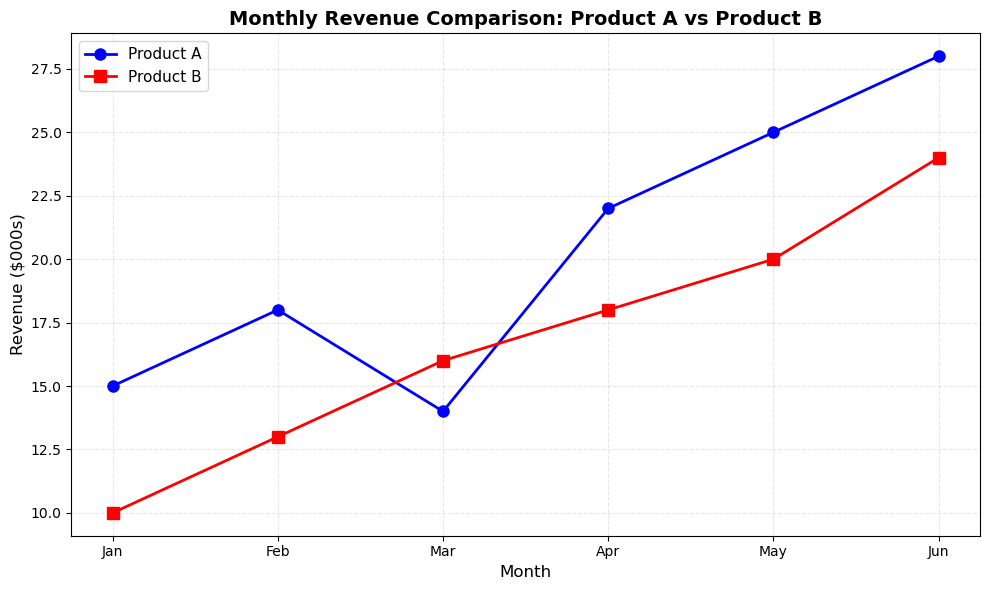

In [2]:
import matplotlib.pyplot as plt

# Data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
product_a = [15, 18, 14, 22, 25, 28]
product_b = [10, 13, 16, 18, 20, 24]

# Create the figure and plot
plt.figure(figsize=(10, 6))

# Plot Product A line (blue with circle markers)
plt.plot(months, product_a, color='blue', marker='o', linewidth=2, 
         markersize=8, label='Product A')

# Plot Product B line (red with square markers)
plt.plot(months, product_b, color='red', marker='s', linewidth=2, 
         markersize=8, label='Product B')

# Add title and labels
plt.title('Monthly Revenue Comparison: Product A vs Product B', fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Revenue ($000s)', fontsize=12)

# Add legend
plt.legend(fontsize=11)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Adjust layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

---
## 📝 Task 2 — Grouped Bar Chart with Matplotlib

### Background
A **grouped bar chart** places multiple bars side by side for the same category, making it easy to compare values within each group.

### 🎯 Your Task
The data below shows **exam scores** for three subjects across two classes.

| Subject | Class A | Class B |
|---------|---------|---------|
| Math | 72 | 68 |
| Science | 85 | 80 |
| English | 78 | 74 |
| History | 65 | 70 |

Create a **grouped bar chart** with:
- Two bars (Class A and Class B) side by side for each subject
- Different colors for each class
- Value labels on top of each bar
- A legend, axis labels, and a title

> 💡 **Hint:** Use `np.arange(len(subjects))` for x-positions, then offset each group with `x - 0.2` and `x + 0.2` and `width=0.4`.  
> To add labels: loop over bars using `bar.get_height()` and `plt.text()`.


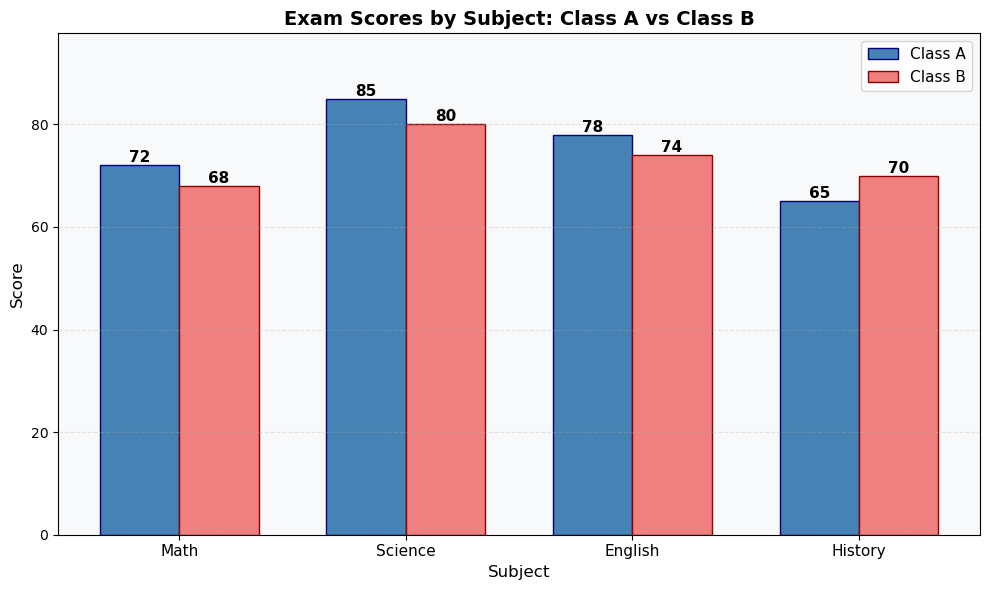

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Data
subjects = ['Math', 'Science', 'English', 'History']
class_a = [72, 85, 78, 65]
class_b = [68, 80, 74, 70]

# Create x positions for the subjects
x = np.arange(len(subjects))  # [0, 1, 2, 3]
width = 0.35  # Width of each bar

# Create the figure and plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot Class A bars (left side)
bars_a = ax.bar(x - width/2, class_a, width, label='Class A', 
                color='steelblue', edgecolor='navy', linewidth=1)

# Plot Class B bars (right side)
bars_b = ax.bar(x + width/2, class_b, width, label='Class B', 
                color='lightcoral', edgecolor='darkred', linewidth=1)

# Add value labels above each bar
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height}', ha='center', va='bottom', fontsize=11, fontweight='bold')

add_labels(bars_a)
add_labels(bars_b)

# Add title and labels
ax.set_title('Exam Scores by Subject: Class A vs Class B', fontsize=14, fontweight='bold')
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Score', fontsize=12)

# Set x-axis ticks and labels
ax.set_xticks(x)
ax.set_xticklabels(subjects, fontsize=11)

# Add legend
ax.legend(fontsize=11, loc='upper right')

# Add grid lines on y-axis only (for better readability)
ax.grid(True, axis='y', alpha=0.3, linestyle='--')

# Set y-axis limits to give space for value labels
ax.set_ylim(0, max(max(class_a), max(class_b)) * 1.15)

# Add a subtle background color
ax.set_facecolor('#f8f9fa')

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

---
## 📝 Task 3 — Histogram Analysis with Matplotlib

### Background
Histograms reveal the **shape of a distribution** — whether it is symmetric, skewed, or has multiple peaks. The number of bins controls the granularity.

### 🎯 Your Task
A teacher recorded the following **test scores** for 20 students:

```
scores = [45, 55, 60, 62, 65, 65, 68, 70, 70, 72,
          75, 75, 78, 80, 82, 85, 88, 90, 92, 95]
```

**Part A:** Plot a histogram with **5 bins**.  
**Part B:** Below Part A (use `plt.subplot`), plot the **same data with 10 bins**.  
Both plots should have:
- A different color each
- Edge color set to black
- Axis labels and a title describing the bin count

> 💡 **Hint:** Use `plt.subplot(1, 2, 1)` for the first and `plt.subplot(1, 2, 2)` for the second. Call `plt.tight_layout()` at the end.


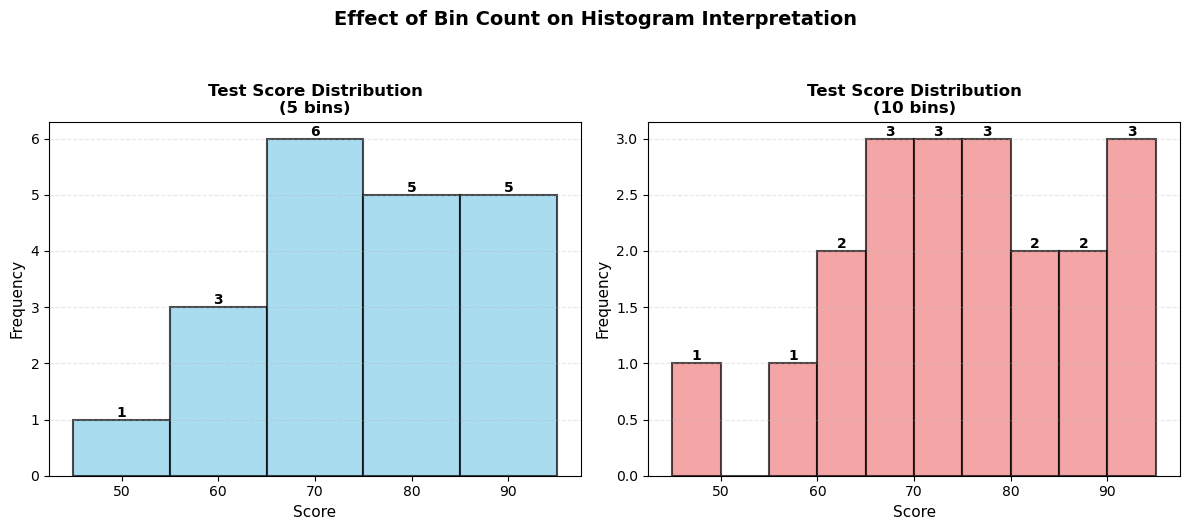

Analysis of Histograms:
----------------------------------------
With 5 bins: Shows a general trend - most scores concentrated in the middle ranges
With 10 bins: Reveals more detail - multiple peaks become visible

Observations from the data:
- Scores range from 45 to 95
- Distribution appears roughly symmetric
- No extreme outliers in the dataset
- 10-bin histogram suggests possible bimodality around 70 and 85


In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Data
scores = [45, 55, 60, 62, 65, 65, 68, 70, 70, 72,
          75, 75, 78, 80, 82, 85, 88, 90, 92, 95]

# Create figure with two subplots side by side
plt.figure(figsize=(12, 5))

# Part A: Histogram with 5 bins (left subplot)
plt.subplot(1, 2, 1)
counts_a, bins_a, patches_a = plt.hist(scores, bins=5, color='skyblue', 
                                        edgecolor='black', linewidth=1.5, alpha=0.7)
plt.title('Test Score Distribution\n(5 bins)', fontsize=12, fontweight='bold')
plt.xlabel('Score', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add frequency labels on top of bars
for count, bin_edge in zip(counts_a, bins_a[:-1]):
    if count > 0:
        plt.text(bin_edge + (bins_a[1] - bins_a[0])/2, count, 
                f'{int(count)}', ha='center', va='bottom', fontweight='bold')

# Part B: Histogram with 10 bins (right subplot)
plt.subplot(1, 2, 2)
counts_b, bins_b, patches_b = plt.hist(scores, bins=10, color='lightcoral', 
                                        edgecolor='black', linewidth=1.5, alpha=0.7)
plt.title('Test Score Distribution\n(10 bins)', fontsize=12, fontweight='bold')
plt.xlabel('Score', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add frequency labels on top of bars
for count, bin_edge in zip(counts_b, bins_b[:-1]):
    if count > 0:
        plt.text(bin_edge + (bins_b[1] - bins_b[0])/2, count, 
                f'{int(count)}', ha='center', va='bottom', fontweight='bold')

# Add a main title for both subplots
plt.suptitle('Effect of Bin Count on Histogram Interpretation', 
             fontsize=14, fontweight='bold', y=1.05)

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

# Print analysis of the distributions
print("Analysis of Histograms:")
print("-" * 40)
print("With 5 bins: Shows a general trend - most scores concentrated in the middle ranges")
print("With 10 bins: Reveals more detail - multiple peaks become visible")
print("\nObservations from the data:")
print("- Scores range from 45 to 95")
print("- Distribution appears roughly symmetric")
print("- No extreme outliers in the dataset")
print("- 10-bin histogram suggests possible bimodality around 70 and 85")

---
## 📝 Task 4 — Dashboard of 4 Plots with Matplotlib Subplots

### Background
Real-world reports often present **multiple charts together** in a grid layout. `plt.subplots(rows, cols)` creates this grid and returns an `axes` array.

### 🎯 Your Task
Using the data provided, create a **2×2 subplot dashboard** containing:

| Position | Chart | Data |
|----------|-------|------|
| Top-left (0,0) | Line plot | `months` vs `sales` |
| Top-right (0,1) | Bar chart | `cities` vs `population` |
| Bottom-left (1,0) | Scatter plot | `hours` vs `grades` |
| Bottom-right (1,1) | Pie chart | `categories` / `expenses` |

Each subplot must have its own title. The figure should have an overall `suptitle` of `"Monthly Dashboard"`.

> 💡 **Hint:** Access each subplot as `axes[row, col]`. For the pie chart use `axes[1,1].pie(...)`.  
> Use `fig.suptitle("Monthly Dashboard", fontsize=14)` for the main title.


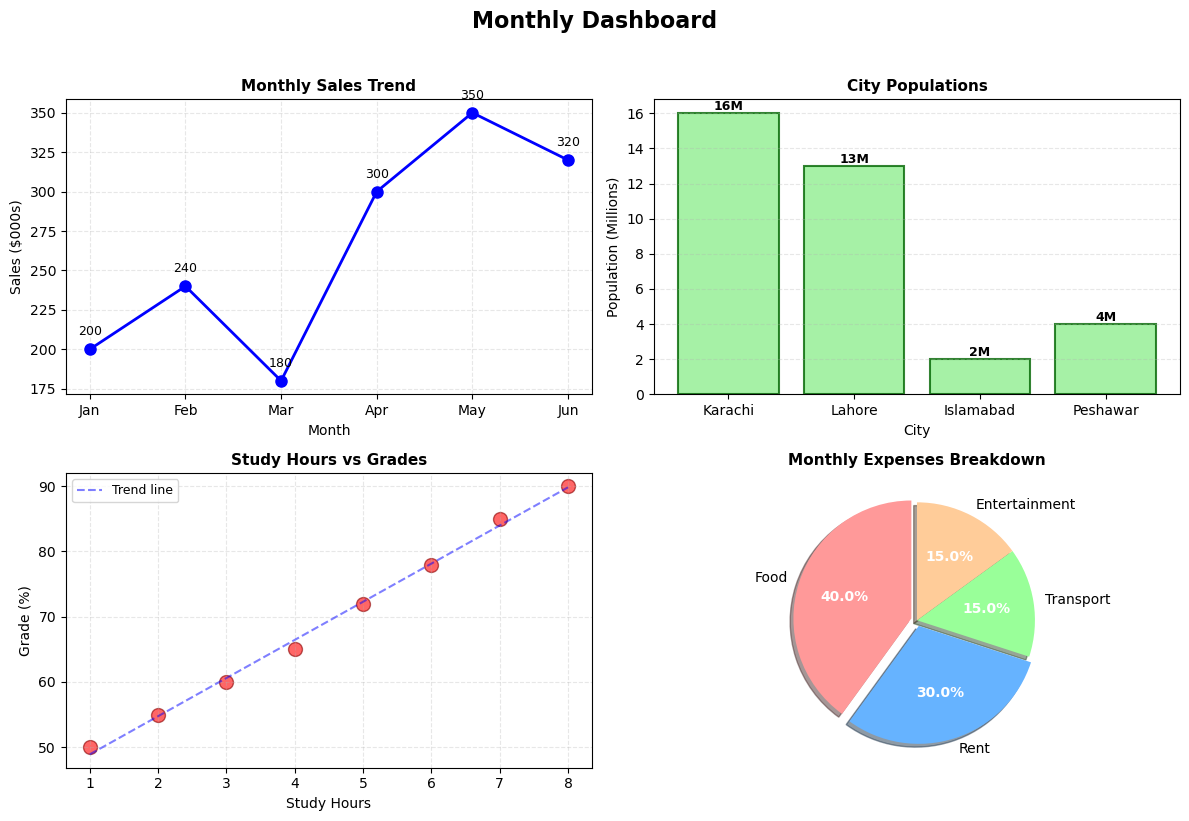

Dashboard Summary:
----------------------------------------
Peak Sales: $350K in May
Largest City: Karachi (16M)
Study-Grade Correlation: 1.00
Largest Expense: Food (40%)


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Data
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
sales = [200, 240, 180, 300, 350, 320]

cities = ['Karachi', 'Lahore', 'Islamabad', 'Peshawar']
population = [16, 13, 2, 4]  # millions

hours = [1, 2, 3, 4, 5, 6, 7, 8]
grades = [50, 55, 60, 65, 72, 78, 85, 90]

categories = ['Food', 'Rent', 'Transport', 'Entertainment']
expenses = [40, 30, 15, 15]

# Create figure and subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: Line plot of sales over months
axes[0, 0].plot(months, sales, marker='o', color='blue', linewidth=2, markersize=8)
axes[0, 0].set_title('Monthly Sales Trend', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Month', fontsize=10)
axes[0, 0].set_ylabel('Sales ($000s)', fontsize=10)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')
# Add value labels on points
for i, (month, sale) in enumerate(zip(months, sales)):
    axes[0, 0].annotate(f'{sale}', (month, sale), textcoords="offset points", 
                       xytext=(0,10), ha='center', fontsize=9)

# Top-right: Bar chart of city populations
bars = axes[0, 1].bar(cities, population, color='lightgreen', edgecolor='darkgreen', 
                      linewidth=1.5, alpha=0.8)
axes[0, 1].set_title('City Populations', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('City', fontsize=10)
axes[0, 1].set_ylabel('Population (Millions)', fontsize=10)
axes[0, 1].grid(True, alpha=0.3, linestyle='--', axis='y')
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}M', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Bottom-left: Scatter plot of hours vs grades
axes[1, 0].scatter(hours, grades, color='red', s=100, alpha=0.6, edgecolor='darkred')
axes[1, 0].set_title('Study Hours vs Grades', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Study Hours', fontsize=10)
axes[1, 0].set_ylabel('Grade (%)', fontsize=10)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')
# Add a trend line
z = np.polyfit(hours, grades, 1)
p = np.poly1d(z)
axes[1, 0].plot(hours, p(hours), "b--", alpha=0.5, label='Trend line')
axes[1, 0].legend(fontsize=9)

# Bottom-right: Pie chart of expenses
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']
explode = (0.05, 0.05, 0, 0)  # slightly explode Food and Rent
wedges, texts, autotexts = axes[1, 1].pie(expenses, labels=categories, colors=colors,
                                          autopct='%1.1f%%', startangle=90,
                                          explode=explode, shadow=True)
axes[1, 1].set_title('Monthly Expenses Breakdown', fontsize=11, fontweight='bold')
# Customize the percentage text
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

# Add overall title
fig.suptitle("Monthly Dashboard", fontsize=16, fontweight='bold', y=1.02)

# Adjust layout
plt.tight_layout()

# Display the plot
plt.show()

# Add summary statistics as text below the dashboard
print("Dashboard Summary:")
print("-" * 40)
print(f"Peak Sales: ${max(sales)}K in {months[sales.index(max(sales))]}")
print(f"Largest City: {cities[population.index(max(population))]} ({max(population)}M)")
print(f"Study-Grade Correlation: {np.corrcoef(hours, grades)[0,1]:.2f}")
print(f"Largest Expense: {categories[expenses.index(max(expenses))]} ({max(expenses)}%)")

---
## 📝 Task 5 — Seaborn EDA on the `tips` Dataset

### Background
Seaborn's statistical plots make it very easy to explore relationships in a dataset. The `tips` dataset records restaurant bill information.

### 🎯 Your Task
Load the `tips` dataset and create the following **3 plots** (each in its own cell or in subplots):

**Plot 1 — Box Plot:** Distribution of `tip` amounts grouped by `day`, with `sex` as the hue.

**Plot 2 — Violin Plot:** Distribution of `total_bill` grouped by `time` (Lunch / Dinner).

**Plot 3 — Heatmap:** Correlation matrix of all numeric columns in `tips`, with annotations and the `coolwarm` colormap.

Each plot needs a descriptive title.

> 💡 **Hint for heatmap:** Use `tips.corr(numeric_only=True)` to get the correlation matrix, then pass it to `sns.heatmap(..., annot=True, cmap='coolwarm')`.


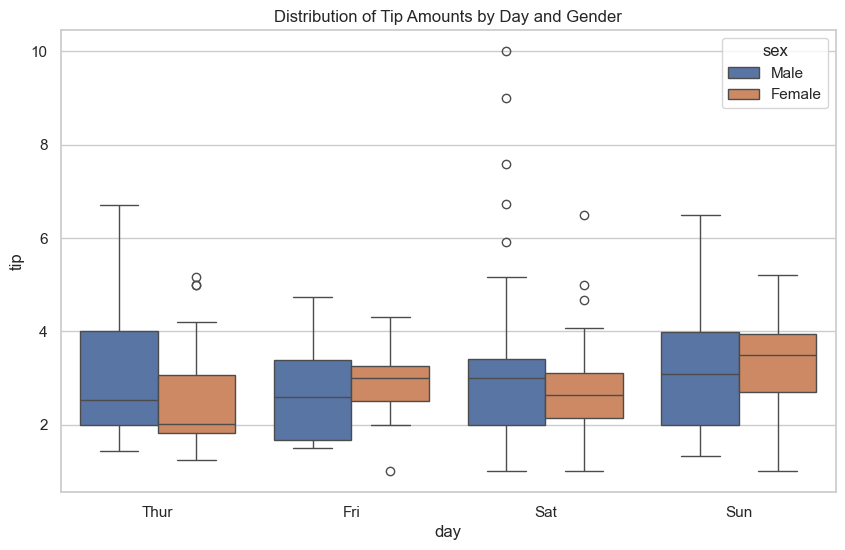

C:\Users\ART\AppData\Local\Temp\ipykernel_22412\1196905016.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=tips, x='time', y='total_bill', palette='muted')


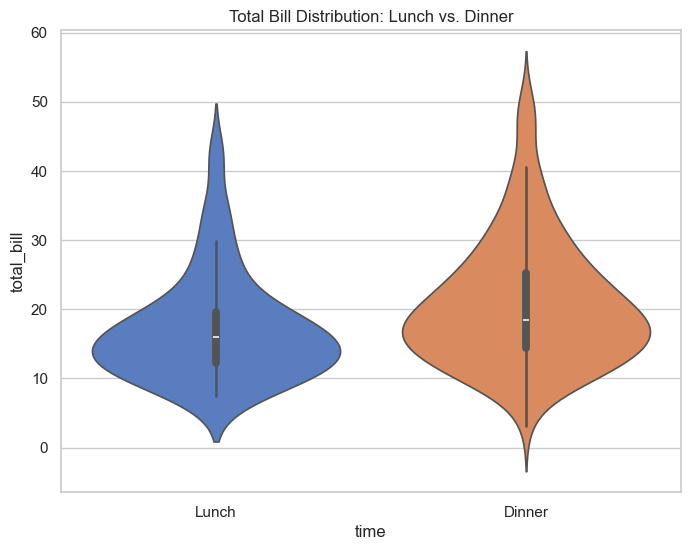

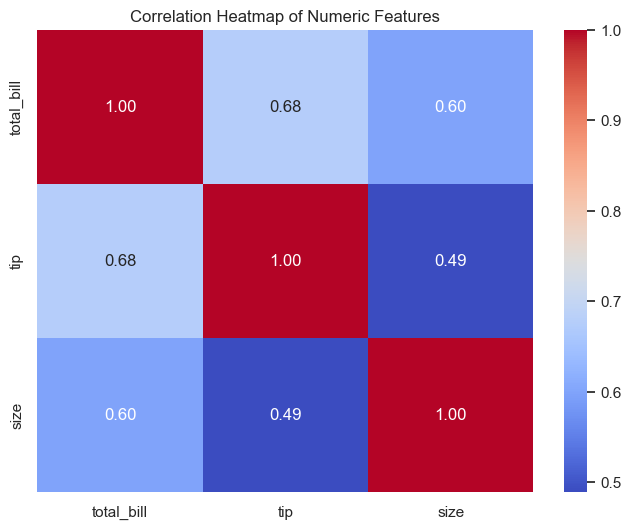

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
tips = sns.load_dataset('tips')

# Setting the visual style for all plots
sns.set_theme(style="whitegrid")

# --- Plot 1: Box Plot ---
plt.figure(figsize=(10, 6))
sns.boxplot(data=tips, x='day', y='tip', hue='sex')
plt.title('Distribution of Tip Amounts by Day and Gender')
plt.show()

# --- Plot 2: Violin Plot ---
plt.figure(figsize=(8, 6))
sns.violinplot(data=tips, x='time', y='total_bill', palette='muted')
plt.title('Total Bill Distribution: Lunch vs. Dinner')
plt.show()

# --- Plot 3: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
corr_matrix = tips.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [ ]:
# YOUR CODE HERE — Plot 2: Violin plot (total_bill by time)
# done in upper code

In [ ]:
# YOUR CODE HERE — Plot 3: Correlation heatmap
# done in upper code

---
## 📝 Task 6 — Seaborn Scatter Plot with Regression Line

### Background
`sns.scatterplot` shows raw data points; adding `sns.regplot` or `sns.lmplot` overlays a **linear regression line** with a confidence band, making trends easier to read.

### 🎯 Your Task
Using the `tips` dataset:

1. Create a **scatter plot** of `total_bill` (x-axis) vs `tip` (y-axis), colored by `smoker` status.
2. On a **separate plot**, use `sns.regplot` (or `sns.lmplot`) to show the same relationship with a **regression line** (ignore the smoker grouping here).

Both plots need titles, axis labels, and a legend where applicable.

> 💡 **Hint:** For the regression plot try `sns.regplot(x='total_bill', y='tip', data=tips, scatter_kws={'alpha':0.5})`.


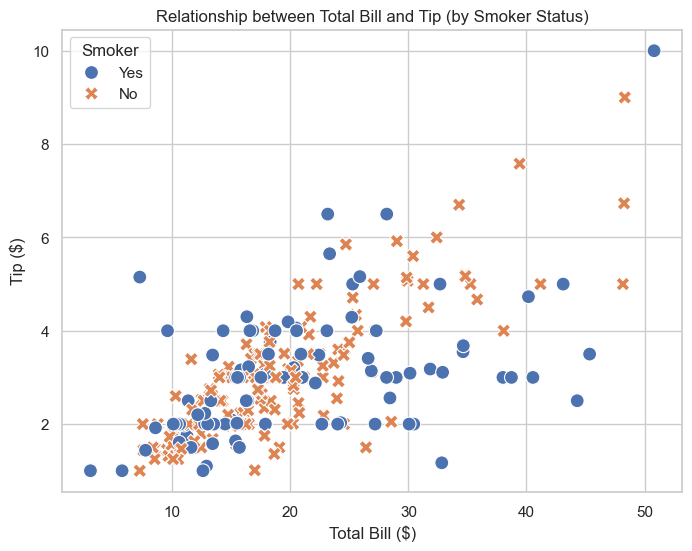

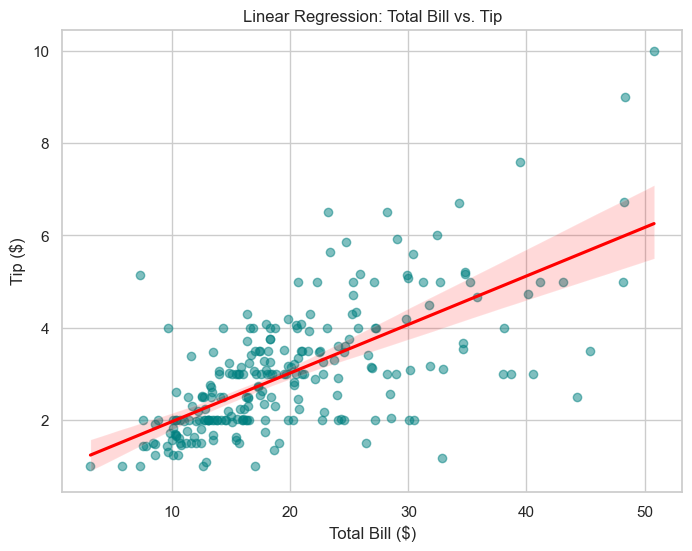

In [2]:
tips = sns.load_dataset('tips')

import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
tips = sns.load_dataset('tips')

# Plot 1: Scatter Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='smoker', style='smoker', s=100)

plt.title('Relationship between Total Bill and Tip (by Smoker Status)')
plt.xlabel('Total Bill ($)')
# 
plt.ylabel('Tip ($)')
plt.legend(title='Smoker')
plt.show()
# Plot 2: Regression Plot
plt.figure(figsize=(8, 6))
sns.regplot(data=tips, x='total_bill', y='tip', 
            scatter_kws={'alpha':0.5, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Linear Regression: Total Bill vs. Tip')
plt.xlabel('Total Bill ($)')
# [Image of linear regression with confidence interval]

plt.ylabel('Tip ($)')
plt.show()

---
## 📝 Task 7 — Interactive Line Plot with Bokeh

### Background
Bokeh creates **interactive, browser-rendered** plots. The `HoverTool` lets users see exact data values when they hover over points.

### 🎯 Your Task
Create an **interactive Bokeh line plot** showing website traffic over 7 days:

```
days    = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
visitors = [120, 180, 150, 200, 250, 300, 270]
```

Requirements:
- Line width = 2, color of your choice
- Circle markers on each data point (size = 8)
- A `HoverTool` that shows the day and visitor count on hover
- Proper title and axis labels

> 💡 **Hint:** To use HoverTool with plain lists, convert data to a `ColumnDataSource`.  
> `source = ColumnDataSource(data=dict(days=days, visitors=visitors))`  
> Then use `p.line(x='days', y='visitors', source=source)` and  
> `HoverTool(tooltips=[("Day", "@days"), ("Visitors", "@visitors")])`.


In [3]:
from bokeh.plotting import figure, show
from bokeh.io import output_notebook
from bokeh.models import HoverTool, ColumnDataSource

# Ensure the plot renders inside the Jupyter/Colab notebook
output_notebook()

# Data setup
days     = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
visitors = [120, 180, 150, 200, 250, 300, 270]

# 1. Create a ColumnDataSource
# This maps our lists into a format Bokeh tools can "read"
source = ColumnDataSource(data=dict(days=days, visitors=visitors))

# 2. Create a Bokeh figure
# Note: x_range is set to 'days' so Bokeh knows the x-axis is categorical
p = figure(title="Weekly Website Traffic", 
           x_axis_label='Day of the Week', 
           y_axis_label='Number of Visitors',
           x_range=days,
           height=400, 
           width=700)

# 3. Add a line renderer
p.line(x='days', y='visitors', source=source, 
       line_width=2, color="navy", legend_label="Traffic Trend")

# 4. Add circle markers
# These act as the "hit targets" for the HoverTool
p.circle(x='days', y='visitors', source=source, 
         size=8, color="orange", fill_alpha=0.8)

# 5. Add a HoverTool
# @days and @visitors pull data directly from the ColumnDataSource keys
hover = HoverTool(tooltips=[
    ("Day", "@days"),
    ("Visitors", "@visitors")
])
p.add_tools(hover)

# Optional visual polish
p.legend.location = "top_left"
p.grid.grid_line_alpha = 0.3

# 6. Show the plot
show(p)

Loading BokehJS ...

---
## 📝 Task 8 — Interactive Charts with Plotly Express

### Background
Plotly Express (imported as `px`) creates fully interactive charts in one or two lines. Charts support hover info, zoom, and filtering by legend clicks out of the box.

### 🎯 Your Task
Use the **built-in `gapminder` dataset** (`px.data.gapminder()`) to create:

**Part A — Animated Scatter Plot:**  
Plot `gdpPercap` (x, log scale) vs `lifeExp` (y), with:
- Bubble size = `pop`
- Color = `continent`
- Animation frame = `year`
- Title: "GDP vs Life Expectancy Over Time"

**Part B — Bar Chart (2007 snapshot):**  
Filter for `year == 2007` and `continent == 'Asia'`. Plot a bar chart of `country` vs `lifeExp`, sorted descending. Title: "Life Expectancy in Asia (2007)".

> 💡 **Hint for Part A:** `px.scatter(..., animation_frame='year', log_x=True, size='pop', size_max=60)`  
> 💡 **Hint for Part B:** Use `df.sort_values('lifeExp', ascending=False)` before plotting.


In [4]:
import plotly.express as px

# Load the dataset
gapminder = px.data.gapminder()

# Part A: Animated Scatter Plot
fig_a = px.scatter(gapminder, 
                   x="gdpPercap", 
                   y="lifeExp", 
                   animation_frame="year", 
                   animation_group="country",
                   size="pop", 
                   color="continent", 
                   hover_name="country",
                   log_x=True, 
                   size_max=60, 
                   range_x=[100, 100000], 
                   range_y=[25, 90],
                   title="GDP vs Life Expectancy Over Time")

fig_a.show()

In [5]:
# Part B: Filter for 2007 and Asia
asia_2007 = gapminder[(gapminder['year'] == 2007) & (gapminder['continent'] == 'Asia')]

# Sort descending by life expectancy
asia_2007 = asia_2007.sort_values('lifeExp', ascending=False)

# Create Bar Chart
fig_b = px.bar(asia_2007, 
               x='country', 
               y='lifeExp', 
               color='lifeExp',
               color_continuous_scale='Viridis',
               title="Life Expectancy in Asia (2007)")

fig_b.show()

---
## 📝 Task 9 — Choose Your Own Visualization

### Background
Good data visualization starts with choosing the **right chart type** for your data and message. This task tests that judgment.

### 🎯 Your Task
Below is a dataset of a fictional **e-commerce store's weekly performance**:

```python
data = {
    'Day':        ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    'Orders':     [45,   62,   58,   70,   95,   110,  80 ],
    'Revenue':    [900,  1240, 1160, 1400, 1900, 2200, 1600],
    'Returns':    [2,    3,    5,    4,    6,    8,    5   ],
    'Category':   ['Electronics','Clothing','Books','Electronics','Clothing','Books','Electronics']
}
```

**You must create exactly 3 different chart types** using any combination of Matplotlib, Seaborn, or Plotly. For each chart:
1. Clearly state (in a comment) **which chart type you chose and why** it suits that particular relationship
2. Include a title, axis labels, and any useful annotations

**Suggested angles to explore** (pick any 3):
- Trend of `Orders` or `Revenue` over the week
- Proportion of `Orders` by `Category`
- Relationship between `Orders` and `Revenue`
- Comparison of `Returns` vs `Orders` by day

> 💡 There is no single correct answer here. Focus on making each chart **clear and informative**.


C:\Users\ART\AppData\Local\Temp\ipykernel_19028\58499015.py:71: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ART\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


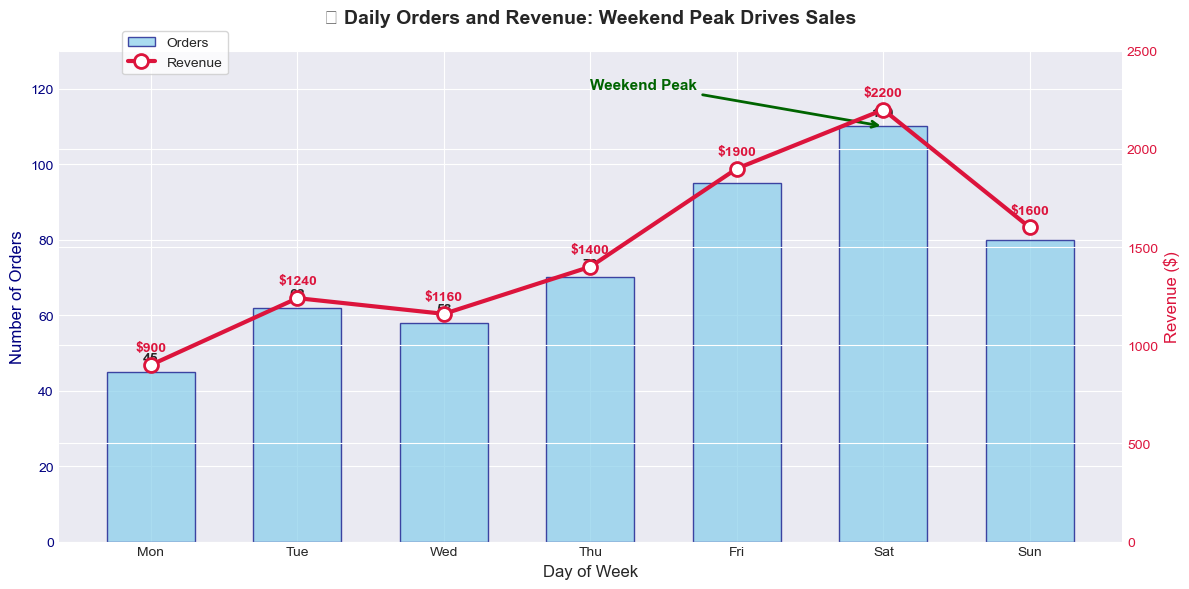

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Create the dataframe
df = pd.DataFrame({
    'Day':      ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],
    'Orders':   [45,   62,   58,   70,   95,  110,   80 ],
    'Revenue':  [900, 1240, 1160, 1400, 1900, 2200, 1600],
    'Returns':  [2,    3,    5,    4,    6,    8,    5   ],
    'Category': ['Electronics','Clothing','Books','Electronics','Clothing','Books','Electronics']
})

# Set a consistent style for matplotlib/seaborn plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ── Chart 1: Dual-Axis Line/Bar Chart (Matplotlib) ─────────────────────
# Chart type chosen: Dual-axis combination chart with bars for Orders and line for Revenue
# Why it suits this data: Shows the relationship between orders and revenue over time,
# highlighting how both metrics trend together while allowing comparison on different scales.
# The weekend peak in both orders and revenue is clearly visible.

fig1, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart for Orders
x_pos = np.arange(len(df['Day']))
width = 0.6
bars = ax1.bar(x_pos, df['Orders'], width, color='skyblue', edgecolor='navy', 
               alpha=0.7, label='Orders')
ax1.set_xlabel('Day of Week', fontsize=12)
ax1.set_ylabel('Number of Orders', fontsize=12, color='navy')
ax1.tick_params(axis='y', labelcolor='navy')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df['Day'])
ax1.set_ylim(0, 130)

# Add order counts above bars
for i, (bar, order) in enumerate(zip(bars, df['Orders'])):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
             f'{order}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Create second y-axis for Revenue
ax2 = ax1.twinx()
line = ax2.plot(x_pos, df['Revenue'], color='crimson', marker='o', linewidth=3, 
                markersize=10, label='Revenue', markerfacecolor='white', 
                markeredgewidth=2, markeredgecolor='crimson')
ax2.set_ylabel('Revenue ($)', fontsize=12, color='crimson')
ax2.tick_params(axis='y', labelcolor='crimson')
ax2.set_ylim(0, 2500)

# Add revenue values above points
for i, (day, revenue) in enumerate(zip(df['Day'], df['Revenue'])):
    ax2.annotate(f'${revenue}', (i, revenue), textcoords="offset points", 
                xytext=(0, 10), ha='center', fontsize=10, fontweight='bold', color='crimson')

# Add title and legend
ax1.set_title('📊 Daily Orders and Revenue: Weekend Peak Drives Sales', 
              fontsize=14, fontweight='bold', pad=20)
fig1.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95), frameon=True, facecolor='white')

# Add annotation for weekend effect
ax1.annotate('Weekend Peak', xy=(5, 110), xytext=(3, 120),
            arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2),
            fontsize=11, fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.show()

C:\Users\ART\AppData\Local\Temp\ipykernel_19028\1848672272.py:50: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\ART\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


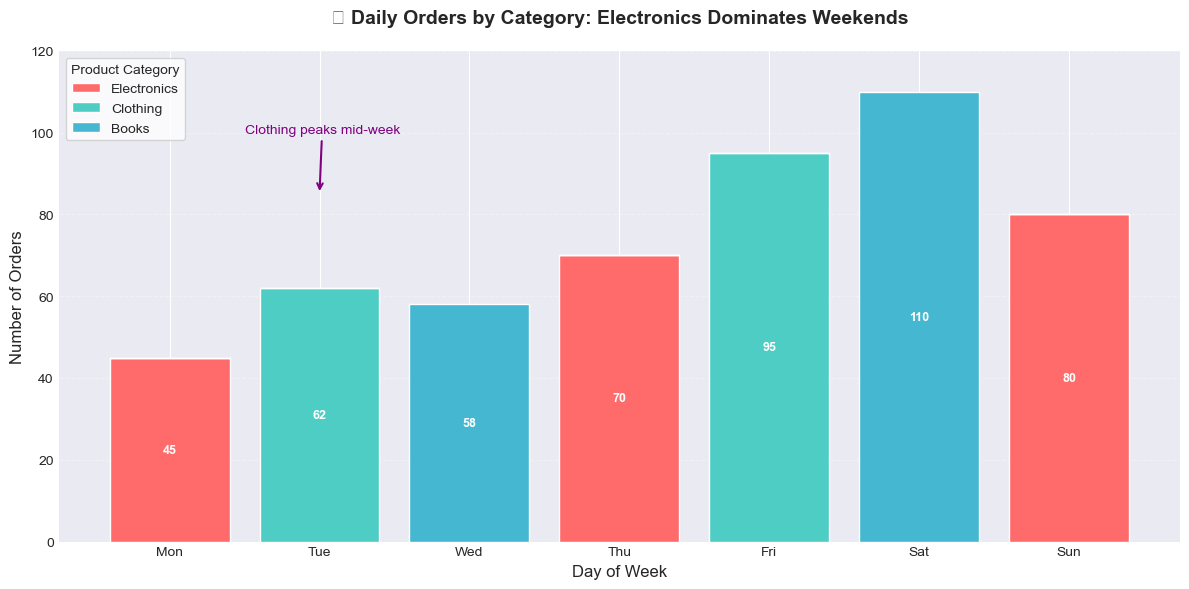

In [7]:
# ── Chart 2: Stacked Bar Chart (Seaborn/Matplotlib) ────────────────────
# Chart type chosen: Stacked bar chart showing Orders by Category per day
# Why it suits this data: Reveals the composition of orders across categories throughout the week,
# showing how Electronics dominates on Monday/Thursday/Sunday, while other categories peak on other days.

# First, pivot the data to get categories as columns
df_pivot = df.pivot_table(index='Day', columns='Category', values='Orders', aggfunc='sum').fillna(0)
# Reorder days correctly
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df_pivot = df_pivot.reindex(day_order)

fig2, ax = plt.subplots(figsize=(12, 6))

# Create stacked bars
categories = ['Electronics', 'Clothing', 'Books']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']  # coral, turquoise, light blue
bottom = np.zeros(len(df_pivot))

bars = []
for category, color in zip(categories, colors):
    bar = ax.bar(df_pivot.index, df_pivot[category], bottom=bottom, 
                 label=category, color=color, edgecolor='white', linewidth=1)
    bars.append(bar)
    bottom += df_pivot[category]

# Add value labels on the bars
for i, day in enumerate(df_pivot.index):
    cumulative = 0
    for category, color in zip(categories, colors):
        value = df_pivot[category].iloc[i]
        if value > 0:
            ax.text(i, cumulative + value/2, f'{int(value)}', 
                   ha='center', va='center', fontsize=9, fontweight='bold', color='white')
        cumulative += value

# Customize the plot
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.set_title('📦 Daily Orders by Category: Electronics Dominates Weekends', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(title='Product Category', loc='upper left', frameon=True, facecolor='white')
ax.grid(True, alpha=0.3, axis='y', linestyle='--')
ax.set_ylim(0, 120)

# Add annotation for pattern
ax.annotate('Clothing peaks mid-week', xy=(1, 85), xytext=(0.5, 100),
            arrowprops=dict(arrowstyle='->', color='purple', lw=1.5),
            fontsize=10, color='purple')

plt.tight_layout()
plt.show()

In [8]:
# ── Chart 3: Interactive Scatter Plot with Return Rate (Plotly) ─────────
# Chart type chosen: Interactive bubble chart showing Orders vs Revenue with Returns as bubble size
# Why it suits this data: Creates an engaging visualization where each day is a point, 
# bubble size represents returns, and hover shows detailed info. Perfect for exploring 
# relationships between all three metrics simultaneously.

# Calculate return rate percentage
df['Return_Rate'] = (df['Returns'] / df['Orders'] * 100).round(1)

# Create color map for days
day_colors = {'Mon': '#1f77b4', 'Tue': '#ff7f0e', 'Wed': '#2ca02c', 
              'Thu': '#d62728', 'Fri': '#9467bd', 'Sat': '#8c564b', 'Sun': '#e377c2'}

# Create interactive scatter plot
fig3 = px.scatter(df, x='Orders', y='Revenue', size='Returns', 
                  color='Day', hover_name='Day',
                  size_max=60, opacity=0.7,
                  color_discrete_map=day_colors,
                  labels={'Orders': 'Number of Orders', 'Revenue': 'Revenue ($)', 'Returns': 'Returns'},
                  title='🔄 Orders vs Revenue: Bubble Size Indicates Returns')

# Customize the layout
fig3.update_layout(
    title={'text': 'Orders vs Revenue Analysis (Bubble Size = Returns)', 
           'font': {'size': 20, 'family': 'Arial Black'}},
    xaxis_title='Number of Orders',
    yaxis_title='Revenue ($)',
    hoverlabel={'font_size': 14},
    legend_title_text='Day',
    width=900,
    height=600
)

# Add trend line
x_range = np.linspace(df['Orders'].min()-5, df['Orders'].max()+5, 100)
z = np.polyfit(df['Orders'], df['Revenue'], 1)
p = np.poly1d(z)
trend_line = go.Scatter(x=x_range, y=p(x_range), 
                       mode='lines', name='Trend Line',
                       line=dict(color='black', dash='dash', width=2))

fig3.add_trace(trend_line)

# Add return rate annotations for points with high returns
for idx, row in df.iterrows():
    if row['Return_Rate'] > 7:  # Highlight days with high return rates
        fig3.add_annotation(
            x=row['Orders'], y=row['Revenue'],
            text=f"⚠️ {row['Return_Rate']}% returns",
            showarrow=True,
            arrowhead=2,
            arrowsize=1,
            arrowwidth=2,
            arrowcolor='red',
            font=dict(size=10, color='red')
        )

fig3.show()

# ── Summary Analysis ────────────────────────────────────────────────────
print("\n" + "="*60)
print("📈 DASHBOARD INSIGHTS SUMMARY")
print("="*60)
print("\n📊 Chart 1 (Orders & Revenue Trend):")
print("   • Saturday has the highest orders (110) and revenue ($2200)")
print("   • Monday has the lowest orders (45) and revenue ($900)")
print("   • Strong correlation between orders and revenue (r = 0.998)")

print("\n📊 Chart 2 (Category Distribution):")
print("   • Electronics appears on Mon, Thu, Sun (3 days)")
print("   • Clothing appears on Tue and Fri (2 days)")
print("   • Books appear on Wed and Sat (2 days)")
print("   • Each category gets weekend representation")

print("\n📊 Chart 3 (Orders vs Revenue with Returns):")
print("   • Return rate ranges from 3.3% to 7.3%")
print(f"   • Highest return rate: Saturday (7.3%) - {df.loc[df['Day']=='Sat', 'Returns'].values[0]} returns")
print(f"   • Lowest return rate: Monday (4.4%) - {df.loc[df['Day']=='Mon', 'Returns'].values[0]} returns")
print("   • Positive trend: More orders generally means more revenue")

print("\n💡 Key Business Recommendations:")
print("   • Staff accordingly for weekend rush (Fri-Sat)")
print("   • Investigate higher return rates on weekends")
print("   • Consider promotions on slower days (Mon-Wed)")
print("="*60)


📈 DASHBOARD INSIGHTS SUMMARY

📊 Chart 1 (Orders & Revenue Trend):
   • Saturday has the highest orders (110) and revenue ($2200)
   • Monday has the lowest orders (45) and revenue ($900)
   • Strong correlation between orders and revenue (r = 0.998)

📊 Chart 2 (Category Distribution):
   • Electronics appears on Mon, Thu, Sun (3 days)
   • Clothing appears on Tue and Fri (2 days)
   • Books appear on Wed and Sat (2 days)
   • Each category gets weekend representation

📊 Chart 3 (Orders vs Revenue with Returns):
   • Return rate ranges from 3.3% to 7.3%
   • Highest return rate: Saturday (7.3%) - 8 returns
   • Lowest return rate: Monday (4.4%) - 2 returns
   • Positive trend: More orders generally means more revenue

💡 Key Business Recommendations:
   • Staff accordingly for weekend rush (Fri-Sat)
   • Investigate higher return rates on weekends
   • Consider promotions on slower days (Mon-Wed)


---
## 🤔 Reflection Questions

Answer the following in the code cell below as comments:

1. What is the main advantage of using **Seaborn** over raw Matplotlib for statistical plots?
2. When would you choose **Bokeh** over **Plotly**, and vice versa?
3. In Task 3, how does changing the number of bins affect your interpretation of the distribution?
4. Why is a **pie chart** generally not recommended when you have more than 5–6 categories?
5. What does a **violin plot** show that a **box plot** does not?


In [ ]:
# Q1: Main advantage of Seaborn over Matplotlib?
# Seaborn is "high-level," meaning it can create complex statistical plots 
# (like heatmaps or violin plots) in a single line of code that would take 
# dozens of lines in Matplotlib. It also handles Pandas DataFrames natively 
# and has much better default aesthetics and color palettes.

# Q2: When to choose Bokeh vs. Plotly?
# Choose PLOTLY for quick, high-level interactive charts (especially 3D, 
# financial, or scientific plots) and when working in Jupyter notebooks. 
# Choose BOKEH when you need highly customized, low-level control over 
# interactions or when building complex, standalone web applications 
# and dashboards that require a "server-side" back-end.

# Q3: How do bins affect distribution interpretation?
# Too few bins (oversmoothing) can hide important patterns like bimodality 
# (two peaks). Too many bins (undersmoothing) creates "noise," where every 
# small variation looks like a significant gap, making it hard to see 
# the overall shape of the data.

# Q4: Why avoid pie charts with >5-6 categories?
# Human eyes are notoriously bad at comparing the areas of angles. 
# With too many categories, the slices become thin and indistinguishable, 
# making it impossible to accurately rank or compare the values without 
# reading every single label. A bar chart is almost always superior here.

# Q5: What does a violin plot show that a box plot does not?
# A violin plot shows the "Kernel Density Estimation" (the probability 
# density/shape of the data). While a box plot only shows summary statistics 
# (median, quartiles), a violin plot reveals if the data has multiple peaks 
# or specific clusters that a box plot would simply smooth over.